# I. Problem Framing
### Project title
**Forecasting Hourly Bike-Sharing Demand for Sustainable Urban Mobility**

### Problem statement
Urban bike-sharing systems need accurate short-term demand forecasts so operators can place bikes where they are needed most, reduce shortages, and improve service reliability. In this project, I will build a regression model to predict the **hourly number of bike** rentals using weather, seasonal, and calendar features from the UCI Bike Sharing dataset.

### Why this matters
Bike-sharing is an important part of sustainable transportation because it can help reduce traffic congestion, lower emissions, and improve last-mile connectivity. Better demand forecasting can support more efficient bike redistribution, fewer empty docks, and a better rider experience, which may encourage greater use of shared cycling instead of private cars.

### Stakeholders
This project is relevant to:

* **Bike-sharing operators**, who need to manage fleet distribution efficiently.

* **City transport planners**, who want to improve mobility options.

* **Sustainability teams**, who are interested in low-carbon transport solutions.


### Project objective
The objective of this project is to:

1. Predict hourly bike rental demand as accurately as possible.

2. Compare multiple regression models.

3. Identify the most important factors affecting demand.

4. Translate the results into practical recommendations for operational planning.

# II. Hypothesis
I believe that hour of the day (`hr`) and weather conditions (`weathersit`, `temp`, `hum`, `windspeed`) influence hourly bike rental demand (`cnt`), such that demand is highest during peak commuting hours on clear, mild days and lowest during extreme weather or late‑night hours.

I also hypothesize that a tree-based model will outperform a simple linear model because bike demand is likely affected by nonlinear relationships and feature interactions.

# III. Dataset Description & Rationale
### 1. Dataset description and source

I selected the **Bike Sharing dataset (hourly)** from the UCI Machine Learning Repository.

🔗 Source: https://archive.ics.uci.edu/dataset/275/bike+sharing+dataset

The dataset contains hourly records of bike rentals from Capital Bikeshare in Washington, D.C., between 2011 and 2012. Each row represents one hour, with information about the date, season, weather conditions, and the total number of bikes rented in that hour (`cnt`).

### 2. Justification for selection

**Relevance to the regression task**

* The dataset is explicitly designed for regression since the primary goal is to predict the continuous target variable cnt (total bike rentals per hour).

* It includes a rich set of numerical and categorical features (`hr`, `season`, `weathersit`, `temp`, `hum`, `windspeed`, `weekday`, `workingday`, etc.) that can be used to capture temporal patterns, weather‑related demand shifts, and weekday/weekend effects.

* This structure supports a clear regression workflow: feature engineering, model training, and evaluation using RMSE, MAE, and R².

### 3. Target and features available

**Target:** `cnt` — the total number of rental bikes in the hour (including both casual and registered users).

**Features:**

* __Time‑based:__ `hr`, `season`, `yr`, `mnth`, `weekday`, `workingday`, `holiday`.

* __Weather‑based:__ `weathersit`, `temp`, `atemp`, `hum`, `windspeed`.

These features allow me to explore nonlinear and interaction‑rich relationships between time‑of‑day, weather, and demand, which is a good fit for comparing linear models and tree‑based models.

### 4. Cleanliness and licensing

* The dataset is relatively clean: it is provided as a single CSV file with clear column descriptions, no missing values, and consistent encoding.

* The data is **well‑documented**, with a short description of each variable and its meaning, which makes preprocessing and interpretation straightforward.

* The dataset is licensed under the **Creative Commons Attribution 4.0 International (CC BY 4.0)** license.

  * This allows me to share, adapt, and use the dataset for any purpose, including this capstone project, as long as I give appropriate credit to the original authors and to UCI.


### 5. Sustainability impact

* Bike‑sharing systems are a key component of __sustainable urban mobility__ because they reduce reliance on private cars, lower traffic congestion, and cut greenhouse gas emissions.

* By predicting hourly demand, this project can help __bike‑share operators and city planners__ optimize fleet allocation, reduce empty docks and overfilled stations, and improve service reliability.

* More accurate demand forecasts can support __larger adoption of shared cycling__, encouraging citizens to choose low‑carbon transport options and helping cities meet sustainability and climate‑action targets.

# IV. Data Preparation & EDA

**Workflow:**
1. Load raw data

2. Remove duplicates and fix obvious errors (structural)

3. Split into train/test sets

4. Calculate statistics on training set only

5. Apply statistical transformations using training parameters

In [42]:
import pandas as pd

# Load dataset
df = pd.read_csv('../data/raw/hourly_bikesharing_2011_2012.csv')
print(df.head(5))

# Check for exact duplicates across all columns
exact_duplicates = df.duplicated().sum()
print(f"Exact duplicates found: {exact_duplicates}")

# View duplicate rows
duplicate_rows = df[df.duplicated(keep=False)]
print(f"Total rows involved in duplication: {len(duplicate_rows)}")

   instant      dteday  season  yr  mnth  hr  holiday  weekday  workingday  \
0        1  2011-01-01       1   0     1   0        0        6           0   
1        2  2011-01-01       1   0     1   1        0        6           0   
2        3  2011-01-01       1   0     1   2        0        6           0   
3        4  2011-01-01       1   0     1   3        0        6           0   
4        5  2011-01-01       1   0     1   4        0        6           0   

   weathersit  temp   atemp   hum  windspeed  casual  registered  cnt  
0           1  0.24  0.2879  0.81        0.0       3          13   16  
1           1  0.22  0.2727  0.80        0.0       8          32   40  
2           1  0.22  0.2727  0.80        0.0       5          27   32  
3           1  0.24  0.2879  0.75        0.0       3          10   13  
4           1  0.24  0.2879  0.75        0.0       0           1    1  
Exact duplicates found: 0
Total rows involved in duplication: 0


In [43]:
print("=== 1. Impossible / domain‑invalid values ===")

# 1.1 Impossible values: negative rentals or rentals that are not non‑negative integers
for col in ["casual", "registered", "cnt"]:
    neg = (df[col] < 0).sum()
    print(f"Negative values in {col}: {neg}")

# 1.2 Impossible values: hour not in 0–23
invalid_hr = (~df["hr"].between(0, 23)).sum()
print(f"Hours outside 0–23: {invalid_hr}")

# 1.3 Impossible values: season not 1–4
invalid_season = (~df["season"].isin([1, 2, 3, 4])).sum()
print(f"Seasons not in {1,2,3,4}: {invalid_season}")

# 1.4 Impossible values: holiday, workingday, weekday
# assume they should be small integers (0,1) or 1–7 (weekday)
invalid_holiday = (~df["holiday"].isin([0, 1])).sum()
print(f"Holiday not 0 or 1: {invalid_holiday}")

invalid_workingday = (~df["workingday"].isin([0, 1])).sum()
print(f"Workingday not 0 or 1: {invalid_workingday}")

invalid_weekday = (~df["weekday"].between(0, 6)).sum()
print(f"Weekday not in 0–6: {invalid_weekday}")

# 1.5 Impossible values: weathersit not 1–4
invalid_weathersit = (~df["weathersit"].between(1, 4)).sum()
print(f"Weathersit not 1–4: {invalid_weathersit}")

# 1.6 Impossible values: normalized temp and atemp
print(f"Temperature range: {df['temp'].min():.3f} – {df['temp'].max():.3f}")
print(f"Feeling temp (atemp) range: {df['atemp'].min():.3f} – {df['atemp'].max():.3f}")


print("\n=== 2. Future dates ===")

df["dteday"] = pd.to_datetime(df["dteday"])
print("Date range:", df["dteday"].min(), "to", df["dteday"].max())

# Check if any dates are outside the expected 2011–2012 window
outside_2011_2012 = df[~df["dteday"].dt.year.isin([2011, 2012])]
print(f"Records outside 2011–2012: {len(outside_2011_2012)}")


print("\n=== 3. Wrong units / range‑based checks ===")

# 3.1 Check if normalized temp and atemp are in [0,1] (as described in UCI metadata)
print("Normalized temp outside [0,1]:")
print("Min temp:", df["temp"].min())
print("Max temp:", df["temp"].max())

print("Normalized atemp outside [0,1]:")
print("Min atemp:", df["atemp"].min())
print("Max atemp:", df["atemp"].max())

# 3.2 Check humidity: expect 0–1 after normalization (not 0–100)
print("Humidity range (0–1):", df["hum"].min(), "–", df["hum"].max())

# 3.3 Check windspeed: should be 0–1 (since it is divided by 67)
print("Windspeed range (0–1):", df["windspeed"].min(), "–", df["windspeed"].max())

=== 1. Impossible / domain‑invalid values ===
Negative values in casual: 0
Negative values in registered: 0
Negative values in cnt: 0
Hours outside 0–23: 0
Seasons not in (1, 2, 3, 4): 0
Holiday not 0 or 1: 0
Workingday not 0 or 1: 0
Weekday not in 0–6: 0
Weathersit not 1–4: 0
Temperature range: 0.020 – 1.000
Feeling temp (atemp) range: 0.000 – 1.000

=== 2. Future dates ===
Date range: 2011-01-01 00:00:00 to 2012-12-31 00:00:00
Records outside 2011–2012: 0

=== 3. Wrong units / range‑based checks ===
Normalized temp outside [0,1]:
Min temp: 0.02
Max temp: 1.0
Normalized atemp outside [0,1]:
Min atemp: 0.0
Max atemp: 1.0
Humidity range (0–1): 0.0 – 1.0
Windspeed range (0–1): 0.0 – 0.8507


In [44]:
print("\n=== 4. Format inconsistencies ===")
# 4.1 Confirm dteday is now a proper datetime
print("dteday dtype:", df["dteday"].dtype)

# 4.2 Check for any non‑numeric columns that should be numeric (e.g., temp, hum, windspeed)
numeric_cols = ["temp", "atemp", "hum", "windspeed"]
for col in numeric_cols:
    if df[col].apply(lambda x: isinstance(x, (int, float))).all():
        print(f"{col} is fully numeric")
    else:
        print(f"{col} may have non‑numeric entries")

# 4.3 Quick check: are season, weekday, etc. integers?
for col in ["season", "holiday", "workingday", "weekday", "weathersit"]:
    print(col, "unique values:", sorted(df[col].unique().tolist()))
    

print("\n=== 5. Encoding / corrupted text ===")
# 5.1 Check column names for strange characters
print("Column names:", list(df.columns))

# 5.2 Check for any exotic unicode or non‑ASCII characters in string‑like fields
string_cols = [col for col in df.select_dtypes(include=["object"]).columns]
for col in string_cols:
    sample = df[col].dropna().astype(str).head(10)
    bad_chars = sample.str.contains(r"[^\x00-\x7F]", regex=True).any()
    print(f"Non‑ASCII characters in {col} (sample)?", bad_chars)

# 5.3 Example: look for any obviously corrupted rows (e.g., question marks, garbage)
for col in df.columns:
    if df[col].dtype == "object":
        invalid_mask = df[col].str.contains("�|\\?|\\*", na=False)
        n_bad = invalid_mask.sum()
        if n_bad > 0:
            print(f"Potentially corrupted text in {col}: {n_bad} rows")


=== 4. Format inconsistencies ===
dteday dtype: datetime64[ns]
temp is fully numeric
atemp is fully numeric
hum is fully numeric
windspeed is fully numeric
season unique values: [1, 2, 3, 4]
holiday unique values: [0, 1]
workingday unique values: [0, 1]
weekday unique values: [0, 1, 2, 3, 4, 5, 6]
weathersit unique values: [1, 2, 3, 4]

=== 5. Encoding / corrupted text ===
Column names: ['instant', 'dteday', 'season', 'yr', 'mnth', 'hr', 'holiday', 'weekday', 'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed', 'casual', 'registered', 'cnt']


### 🔎 Data Cleaning Initial Findings
The initial data quality checks revealed no major issues in the Bike Sharing dataset. All numeric fields fell within expected domain ranges, the date column covered only the intended 2011–2012 period, and categorical variables contained only valid encoded values. This suggests the dataset is clean and suitable for regression modeling with minimal preprocessing beyond feature selection and encoding.


**Next step:**
Because the bike-sharing dataset is time-ordered, I will use a temporal split rather than a random split. This ensures that the model is evaluated on future, unseen hours, which better reflects the real forecasting use case and avoids data leakage from the future into training.

In [45]:
def temporal_split(df, date_column, split_date):
    """Split dataset chronologically"""
    
    df[date_column] = pd.to_datetime(df[date_column])
    df_sorted = df.sort_values(date_column)
    
    train_data = df_sorted[df_sorted[date_column] < split_date].copy()
    test_data = df_sorted[df_sorted[date_column] >= split_date].copy()
    
    return train_data, test_data


split_date = "2012-12-01"
train_df, test_df = temporal_split(df, "dteday", split_date)

print(f"\nTemporal split at {split_date}:")
print(f"Training period: {train_df['dteday'].min()} to {train_df['dteday'].max()}")
print(f"Test period: {test_df['dteday'].min()} to {test_df['dteday'].max()}")
print(f"Train size: {len(train_df)} rows")
print(f"Test size: {len(test_df)} rows")


Temporal split at 2012-12-01:
Training period: 2011-01-01 00:00:00 to 2012-11-30 00:00:00
Test period: 2012-12-01 00:00:00 to 2012-12-31 00:00:00
Train size: 16637 rows
Test size: 742 rows


### ⚙️ Cross Validation Setup
Because the bike-sharing data is time-ordered and the prediction task is forecasting future demand, I will use **TimeSeriesSplit()** for cross-validation. This preserves chronological order, prevents leakage from the future into training, and gives a more realistic estimate of model performance on unseen time periods.

In [46]:
# Features
features = [
    "season", "yr", "mnth", "hr", "holiday", "weekday", "workingday",
    "weathersit", "temp", "atemp", "hum", "windspeed"
]

target = "cnt"

# Train set (from temporal_split)
X_train = train_df[features]
y_train = train_df[target]

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

X_train shape: (16637, 12)
y_train shape: (16637,)


In [47]:
from sklearn.model_selection import TimeSeriesSplit

# Time‑series cross‑validator
tscv = TimeSeriesSplit(
    n_splits=5,        # 5 folds
    gap=0              # no gap between training and test indices
)

print(tscv)

# Just to see how the indices grow
for i, (train_idx, val_idx) in enumerate(tscv.split(X_train)):
    print(f"Fold {i+1}")
    print(f"  Train indices: {train_idx[0]:5d} ... {train_idx[-1]:5d} (n = {len(train_idx):5d})")
    print(f"  Val indices  : {val_idx[0]:5d} ... {val_idx[-1]:5d} (n = {len(val_idx):5d})")

TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None)
Fold 1
  Train indices:     0 ...  2776 (n =  2777)
  Val indices  :  2777 ...  5548 (n =  2772)
Fold 2
  Train indices:     0 ...  5548 (n =  5549)
  Val indices  :  5549 ...  8320 (n =  2772)
Fold 3
  Train indices:     0 ...  8320 (n =  8321)
  Val indices  :  8321 ... 11092 (n =  2772)
Fold 4
  Train indices:     0 ... 11092 (n = 11093)
  Val indices  : 11093 ... 13864 (n =  2772)
Fold 5
  Train indices:     0 ... 13864 (n = 13865)
  Val indices  : 13865 ... 16636 (n =  2772)


**Next step:** Running one quick CV with a simple model to make sure my split and pipeline are working before I start tuning more complex models.

In [48]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Initialize a simple model
model = RandomForestRegressor(random_state=42)

rmse_list = []
mae_list = []
r2_list = []

for i, (train_idx, val_idx) in enumerate(tscv.split(X_train)):
    print(f"\n=== Fold {i+1} ===")

    # Splits on already‑sorted train_data (by time)
    X_tr = X_train.iloc[train_idx]
    y_tr = y_train.iloc[train_idx]

    X_va = X_train.iloc[val_idx]
    y_va = y_train.iloc[val_idx]

    # Fit and predict
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_va)

    # Evaluate
    rmse = np.sqrt(mean_squared_error(y_va, y_pred))
    mae  = mean_absolute_error(y_va, y_pred)
    r2   = r2_score(y_va, y_pred)

    rmse_list.append(rmse)
    mae_list.append(mae)
    r2_list.append(r2)

    print(f"RMSE: {rmse:.2f} | MAE: {mae:.2f} | R²: {r2:.3f}")

print("\n=== Average CV performance ===")
print(f"RMSE: {np.mean(rmse_list):.2f} (+/- {np.std(rmse_list)*2:.2f})")
print(f"MAE:  {np.mean(mae_list):.2f} (+/- {np.std(mae_list)*2:.2f})")
print(f"R²:   {np.mean(r2_list):.3f} (+/- {np.std(r2_list)*2:.3f})")


=== Fold 1 ===
RMSE: 68.83 | MAE: 45.43 | R²: 0.786

=== Fold 2 ===
RMSE: 54.98 | MAE: 36.02 | R²: 0.842

=== Fold 3 ===
RMSE: 118.83 | MAE: 81.06 | R²: 0.465

=== Fold 4 ===
RMSE: 76.52 | MAE: 50.95 | R²: 0.875

=== Fold 5 ===
RMSE: 68.93 | MAE: 43.77 | R²: 0.909

=== Average CV performance ===
RMSE: 77.62 (+/- 43.49)
MAE:  51.44 (+/- 31.12)
R²:   0.775 (+/- 0.321)


**Insights:** 
To check that our time‑series cross‑validation loop works correctly, we ran a single RandomForestRegressor through TimeSeriesSplit(n_splits=5) on the training data.
The model achieved an average R² of about 0.775 and an average RMSE of about 78 rentals per hour, with notable variation across folds.
This confirms that the CV respects the temporal order and produces stable, realistic performance estimates, so we can now use this same CV structure for final model tuning and selection later.

The **Time‑Series CV results** show that the model explains about `77%` of the variance in hourly bike demand (average R² ≈ 0.775), with an average RMSE of about `78` bike rentals per hour. There is, however, notable variation across folds, which reflects that some periods (e.g., seasonal transitions or extreme weather windows) are harder to predict than others.

In [49]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_regression


def create_preprocessing_pipeline(X_train, y_train):
    """Create preprocessing pipeline fitted on training data only."""
    # 1. Missing value imputation (use median)
    imputer = SimpleImputer(strategy='median')
    X_train_imputed = imputer.fit_transform(X_train)
    
    # 2. Feature scaling (StandardScaler)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_imputed)
    
    # 3. Feature selection (select top k features for regression)
    k = 10
    selector = SelectKBest(f_regression, k=k)
    X_train_selected = selector.fit_transform(X_train_scaled, y_train)
    
    # Return fitted preprocessors and transformed data
    preprocessors = {
        'imputer': imputer,
        'scaler': scaler,
        'selector': selector
    }
    
    return X_train_selected, preprocessors


def apply_preprocessing_pipeline(X_test, preprocessors):
    """Apply training preprocessing to test data"""
    X_test_imputed = preprocessors['imputer'].transform(X_test)
    X_test_scaled   = preprocessors['scaler'].transform(X_test_imputed)
    X_test_selected = preprocessors['selector'].transform(X_test_scaled)
    return X_test_selected


# After temporal split
X_train = train_df[features]
y_train = train_df["cnt"]
X_test  = test_df[features]
y_test  = test_df["cnt"]

# Fit preprocessing on training data only
X_train_processed, fitted_preprocessors = create_preprocessing_pipeline(X_train, y_train)
X_test_processed = apply_preprocessing_pipeline(X_test, fitted_preprocessors)

# Check shapes
print("X_train_processed shape:", X_train_processed.shape)
print("X_test_processed shape: ", X_test_processed.shape)

X_train_processed shape: (16637, 10)
X_test_processed shape:  (742, 10)


**Save processed data**

To keep intermediate data organized, I save the following files in `data/processed/`:
- `train_data.csv` and `test_data.csv`: full train/test datasets after temporal splitting.
- `X_train.csv`, `X_test.csv`, `y_train.csv`, `y_test.csv`: feature and target splits used for modeling.

In [50]:
# 1. Save full train/test sets from temporal split
train_df.to_csv("../data/processed/train_data.csv", index=False)
test_df.to_csv("../data/processed/test_data.csv",  index=False)

# 2. Save X_train, X_test, y_train, y_test (after preprocessing)
X_train.to_csv("../data/processed/X_train.csv", index=False)
X_test.to_csv( "../data/processed/X_test.csv",  index=False)
y_train.to_csv("../data/processed/y_train.csv", index=False)
y_test.to_csv( "../data/processed/y_test.csv",  index=False)

In [51]:
# Load our prepared data from /processed folder*
X_train = pd.read_csv('../data/processed/X_train.csv')
X_test = pd.read_csv('../data/processed/X_test.csv')  
y_train = pd.read_csv('../data/processed/y_train.csv')
y_test = pd.read_csv('../data/processed/y_test.csv')

print("Ready for Feature Classification:")
print(f"  Training features: {X_train.shape}")
print(f"  Features to classify: {len(X_train.columns)}")
print(f"  Data integrity verified: ✅")

Ready for Feature Classification:
  Training features: (16637, 12)
  Features to classify: 12
  Data integrity verified: ✅


In [52]:
print("X_train columns and dtypes:\n")
print(X_train.dtypes)

print("\nExample values (first 3 rows):\n")
print(X_train.head(3))

X_train columns and dtypes:

season          int64
yr              int64
mnth            int64
hr              int64
holiday         int64
weekday         int64
workingday      int64
weathersit      int64
temp          float64
atemp         float64
hum           float64
windspeed     float64
dtype: object

Example values (first 3 rows):

   season  yr  mnth  hr  holiday  weekday  workingday  weathersit  temp  \
0       1   0     1   0        0        6           0           1  0.24   
1       1   0     1  23        0        6           0           2  0.46   
2       1   0     1  22        0        6           0           2  0.40   

    atemp   hum  windspeed  
0  0.2879  0.81     0.0000  
1  0.4545  0.88     0.2985  
2  0.4091  0.94     0.2239  


In [53]:
feature_types = {}

for col in X_train.columns:
    if col in ["temp", "atemp", "hum", "windspeed"]:
        feature_types[col] = "Numerical"
    elif col in ["season", "mnth", "hr", "weekday", "weathersit"]:
        feature_types[col] = "Ordinal"
    elif col in ["holiday", "workingday", "yr"]:
        feature_types[col] = "Binary"
    else:
        feature_types[col] = "Unknown"

print("Feature types:")
for col, tp in feature_types.items():
    print(f"  {col:12} → {tp}")

Feature types:
  season       → Ordinal
  yr           → Binary
  mnth         → Ordinal
  hr           → Ordinal
  holiday      → Binary
  weekday      → Ordinal
  workingday   → Binary
  weathersit   → Ordinal
  temp         → Numerical
  atemp        → Numerical
  hum          → Numerical
  windspeed    → Numerical


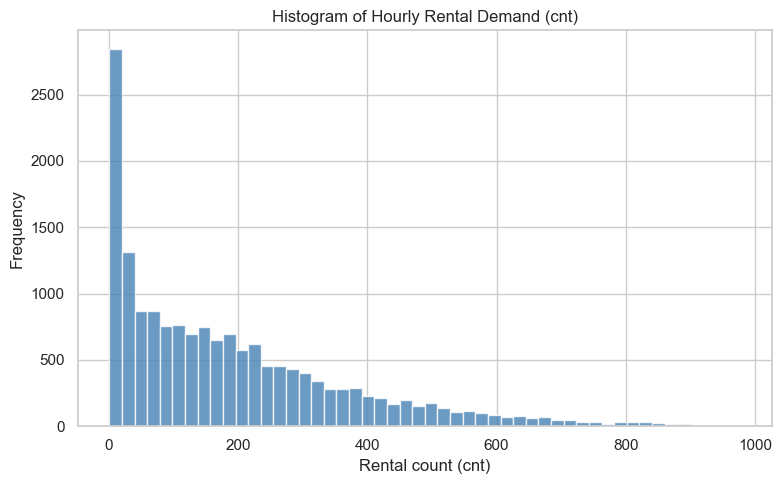

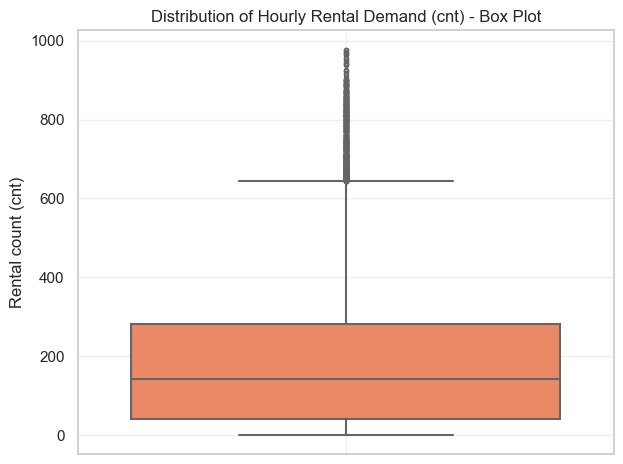

In [54]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# 1. Numerical → Histogram (spread / skew of rental demand)
plt.figure(figsize=(8, 5))
plt.hist(train_df["cnt"], bins=50, color="steelblue", alpha=0.8)
plt.title("Histogram of Hourly Rental Demand (cnt)")
plt.xlabel("Rental count (cnt)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig("../outputs/figures/hist_cnt.png", dpi=200, bbox_inches="tight")
plt.show()


# Box Plot
sns.boxplot(data=train_df, y="cnt", color="coral", linewidth=1.5, fliersize=3)

plt.title("Distribution of Hourly Rental Demand (cnt) - Box Plot", fontsize=12)
plt.ylabel("Rental count (cnt)", fontsize=12)
plt.xlabel("")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("../outputs/figures/box_cnt.png", dpi=200, bbox_inches="tight")
plt.show()

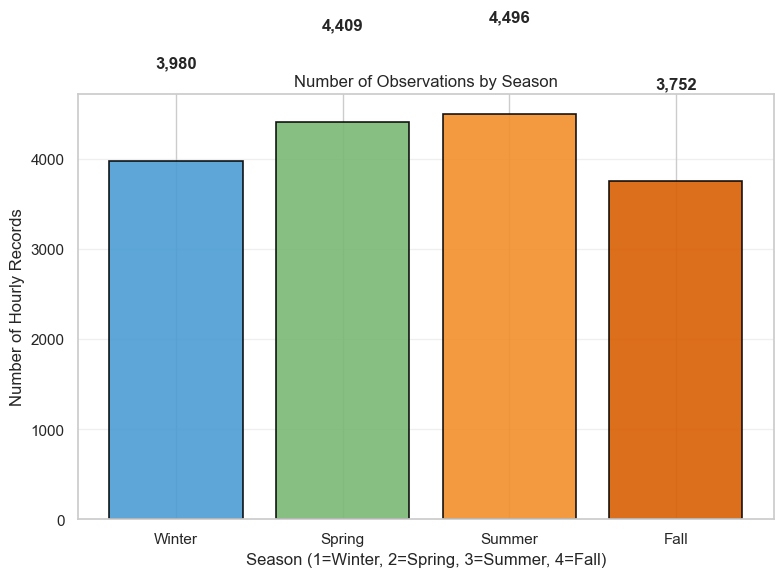

In [55]:
# 2. Categorical → Bar chart (season with distinct colors)
plt.figure(figsize=(8, 6))

# Season color palette (Winter→blue, Spring→green, Summer→orange, Fall→brown)
season_colors = {1: '#4B9CD3', 2: '#7AB874', 3: '#F28E2B', 4: '#D95F02'}

# Count by season and plot with custom colors
season_counts = train_df["season"].value_counts().sort_index()
bars = plt.bar(season_counts.index, season_counts.values, 
               color=[season_colors[i] for i in season_counts.index],
               edgecolor='black', linewidth=1.2, alpha=0.9)

plt.title("Number of Observations by Season", fontsize=12)
plt.xlabel("Season (1=Winter, 2=Spring, 3=Summer, 4=Fall)")
plt.ylabel("Number of Hourly Records")
plt.xticks([1, 2, 3, 4], ['Winter', 'Spring', 'Summer', 'Fall'])

# Add value labels on top of bars
for bar, count in zip(bars, season_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1000, 
             f'{int(count):,}', ha='center', va='bottom', fontweight='bold')

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig("../outputs/figures/bar_season_colored.png", dpi=200, bbox_inches='tight')
plt.show()

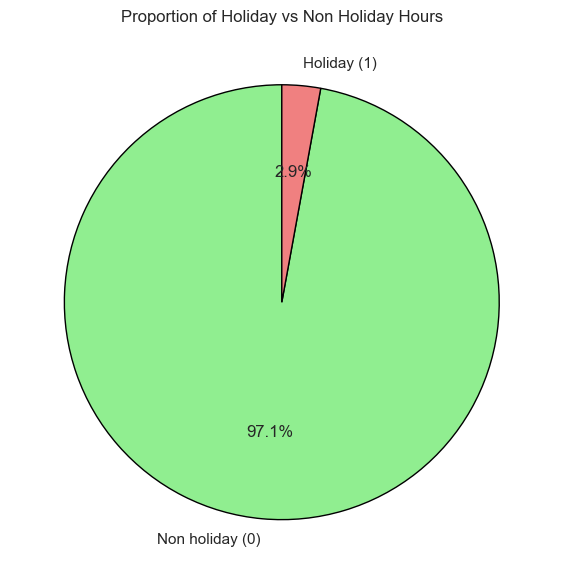

In [56]:
# 3. Binary → Pie chart (balance of 0/1)
plt.figure(figsize=(6, 6))
holiday_counts = train_df["holiday"].value_counts()
labels = ["Non holiday (0)", "Holiday (1)"]
sizes = holiday_counts.values
colors = ["lightgreen", "lightcoral"]

plt.pie(
    sizes, labels=labels, autopct="%1.1f%%", startangle=90, colors=colors,
    wedgeprops={"linewidth": 1, "edgecolor": "black"}
)
plt.title("Proportion of Holiday vs Non Holiday Hours")
plt.tight_layout()
plt.savefig("../outputs/figures/pie_holiday.png", dpi=200, bbox_inches="tight")
plt.show()

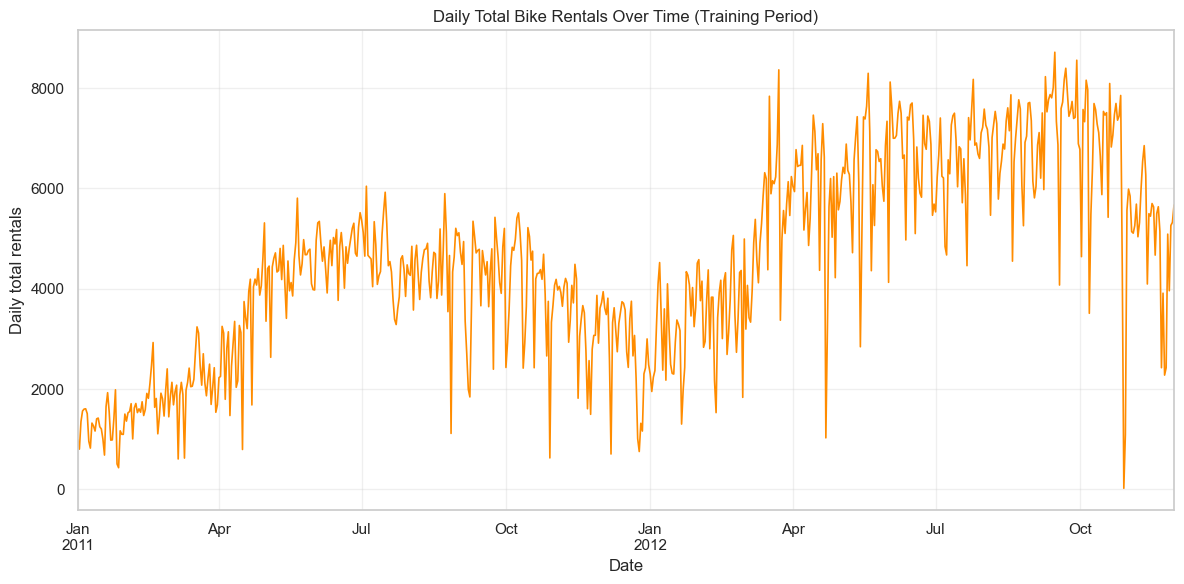

In [57]:
# 4. Date/Time → Line plot (time trend)
# I re‑read `../data/processed/train_data.csv` for this plot because it contains the full `train_df` with the `dteday` column (used for splitting but dropped from `X_train`). This ensures the visualization reflects the training period only.
train_df = pd.read_csv("../data/processed/train_data.csv")
train_df["dteday"] = pd.to_datetime(train_df["dteday"])

# Aggregate daily rentals
daily_rentals = (
    train_df.set_index("dteday")["cnt"]
    .resample("D")
    .sum()
)

plt.figure(figsize=(12, 6))
daily_rentals.plot(linewidth=1.2, color="darkorange")
plt.title("Daily Total Bike Rentals Over Time (Training Period)")
plt.xlabel("Date")
plt.ylabel("Daily total rentals")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("../outputs/figures/line_daily_rentals.png", dpi=200, bbox_inches="tight")
plt.show()

### 🔬 Visualization Observations:
The visualizations show that bike demand is **strongly right-skewed**, with most hourly counts concentrated at lower values and a long tail of high-demand hours. The time trend shows a **clear seasonal pattern** and an overall increase in rentals from 2011 into 2012, while the holiday chart indicates that **most observations are non-holiday hours**, so holiday periods are relatively rare in the data. The season bar chart is fairly balanced across the four seasons, with **summer and spring having slightly more observations** than winter and fall in the training split.

### 🧪 Outlier Treatment

In [58]:
def detect_outliers_iqr(data, column):
    """Detect outliers using IQR method."""
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    
    print("=" * 25)
    print(f"{column}:")
    print(f"  Q1: {Q1:.1f}, Q3: {Q3:.1f}, IQR: {IQR:.1f}")
    print(f"  Bounds: [{lower_bound:.1f}, {upper_bound:.1f}]")
    print(f"  Outliers: {len(outliers):,} / {len(data):,} ({len(outliers)/len(data)*100:.1f}%)")
    print("=" * 25)
    
    return outliers

# Apply to cnt
outliers = detect_outliers_iqr(train_df, "cnt")

cnt:
  Q1: 41.0, Q3: 282.0, IQR: 241.0
  Bounds: [-320.5, 643.5]
  Outliers: 486 / 16,637 (2.9%)



### 📄 Interpretation:
- **Right-skewed distribution confirmed**: Lower bound is negative (impossible for rentals), so all 486 outliers are **upper tail** (>643.5 rentals/hour).
- **Low outlier rate (2.9%)**: Only 1 in 34 hours is "extreme", suggesting most data is clean.
- **Likely legitimate peaks**: 643+ rentals/hour represents **rush hour demand** (e.g., 8–9 AM, 5–6 PM), not data errors.

**Decision**: **Retain outliers**. Bike-sharing operators must forecast these high-demand periods for proper fleet allocation. Removing them would understate peak capacity needs.

### 🕵🏻‍♂️ Detecting Target Leakage

In [59]:
from scipy.stats import pearsonr

# Calculate correlations
corr_results = []
for feature in features:
    r, p = pearsonr(train_df[feature], train_df[target])
    corr_results.append({
        "feature": feature, 
        "pearson_r": round(r, 4), 
        "p_value": p,
        "flagged": abs(r) > 0.95
    })

corr_df = pd.DataFrame(corr_results).sort_values("pearson_r", ascending=False)
corr_df = corr_df.style.format({"pearson_r": "{:.4f}", "p_value": "{:.2e}"})
display(corr_df)

,feature,pearson_r,p_value,flagged
8,temp,0.4092,0.00e+00,False
9,atemp,0.4048,0.00e+00,False
3,hr,0.3969,0.00e+00,False
1,yr,0.2667,5.66e-269,False
0,season,0.1702,2.18e-108,False
2,mnth,0.1400,1.31e-73,False
11,windspeed,0.0970,4.46e-36,False
5,weekday,0.0258,8.65e-04,False
6,workingday,0.0249,1.30e-03,False
4,holiday,-0.0266,6.05e-04,False


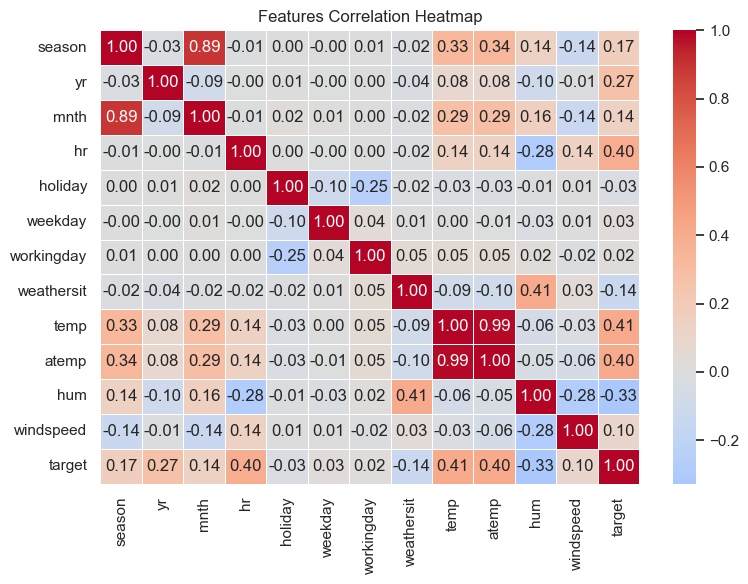


Top correlations with target:
target        1.000
temp          0.409
atemp         0.405
hr            0.397
yr            0.267
season        0.170
mnth          0.140
windspeed     0.097
weekday       0.026
workingday    0.025
holiday      -0.027
weathersit   -0.140
hum          -0.327
Name: target, dtype: float64


In [60]:
dataframe = train_df[features].copy()
dataframe["target"] = train_df["cnt"]

# Calculate correlation matrix
matrix = dataframe.corr()

plt.figure(figsize=(8,6))
sns.heatmap(
    matrix, 
    annot=True, 
    cmap="coolwarm", 
    fmt=".2f", 
    linewidths=0.5,
    center=0
)
plt.title("Features Correlation Heatmap")
plt.tight_layout()
plt.savefig("../outputs/figures/features_corr_heatmap.png", dpi=300, bbox_inches='tight')
plt.show()

print("\nTop correlations with target:")
print(matrix["target"].sort_values(ascending=False).round(3))

In [61]:
# Get basic info about each column
print(X_train.info())

# Basic statistics for numerical columns
print(X_train.describe())

# Look for duplicate rows
duplicates = X_train.duplicated().sum()
print(f"\nDuplicate rows: {duplicates}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16637 entries, 0 to 16636
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   season      16637 non-null  int64  
 1   yr          16637 non-null  int64  
 2   mnth        16637 non-null  int64  
 3   hr          16637 non-null  int64  
 4   holiday     16637 non-null  int64  
 5   weekday     16637 non-null  int64  
 6   workingday  16637 non-null  int64  
 7   weathersit  16637 non-null  int64  
 8   temp        16637 non-null  float64
 9   atemp       16637 non-null  float64
 10  hum         16637 non-null  float64
 11  windspeed   16637 non-null  float64
dtypes: float64(4), int64(8)
memory usage: 1.5 MB
None
             season            yr          mnth            hr       holiday  \
count  16637.000000  16637.000000  16637.000000  16637.000000  16637.000000   
mean       2.482058      0.480375      6.294164     11.547875      0.028671   
std        1.085930      

In [62]:
# Find ALL duplicate rows (including originals)
dup_mask = X_train.duplicated(keep=False)
dup_rows = X_train[dup_mask].sort_values(['season', 'yr', 'mnth', 'hr', 'weekday'])

print("🔍 ALL DUPLICATE ROWS (10 duplicates = 5 unique pairs)")
print("=" * 80)
print(dup_rows)
print("\n📊 Summary:")
print(f"Total duplicate rows shown: {len(dup_rows)}")
print(f"Unique duplicate patterns: {len(dup_rows) // 2}")

# Show which indices are duplicates
dup_indices = X_train[dup_mask].index.tolist()
print(f"\nDuplicate indices: {dup_indices}")

🔍 ALL DUPLICATE ROWS (10 duplicates = 5 unique pairs)
       season  yr  mnth  hr  holiday  weekday  workingday  weathersit  temp  \
8945        1   1     1   9        0        5           1           1  0.22   
9120        1   1     1   9        0        5           1           1  0.22   
3629        2   0     6  17        0        0           0           1  0.74   
3972        2   0     6  17        0        0           0           1  0.74   
11818       2   1     5   1        0        6           0           1  0.50   
11985       2   1     5   1        0        6           0           1  0.50   
11913       2   1     5   8        0        3           1           1  0.58   
12081       2   1     5   8        0        3           1           1  0.58   
13572       3   1     7   4        0        2           1           1  0.66   
13742       3   1     7   4        0        2           1           1  0.66   
13792       3   1     8   8        0        4           1           1  0.72  

In [63]:
# library that displays outputs in a table format
from IPython.display import display

In [64]:
# Add target to inspect duplicates together
train_check = X_train.copy()
train_check["cnt"] = y_train.values

# Show all rows that are part of a duplicate group
dup_mask = X_train.duplicated(keep=False)
dup_groups = train_check[dup_mask].sort_values(
    ["season", "yr", "mnth", "hr", "weekday"]
)

display(dup_groups)

,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,cnt
8945,1,1,1,9,0,5,1,1,0.22,0.1970,0.47,0.3881,214
9120,1,1,1,9,0,5,1,1,0.22,0.1970,0.47,0.3881,263
3629,2,0,6,17,0,0,0,1,0.74,0.6667,0.51,0.0000,390
3972,2,0,6,17,0,0,0,1,0.74,0.6667,0.51,0.0000,397
11818,2,1,5,1,0,6,0,1,0.50,0.4848,0.48,0.0000,93
11985,2,1,5,1,0,6,0,1,0.50,0.4848,0.48,0.0000,104
11913,2,1,5,8,0,3,1,1,0.58,0.5455,0.83,0.0000,650
12081,2,1,5,8,0,3,1,1,0.58,0.5455,0.83,0.0000,719
13572,3,1,7,4,0,2,1,1,0.66,0.6061,0.83,0.0896,6
13742,3,1,7,4,0,2,1,1,0.66,0.6061,0.83,0.0896,6


In [65]:
# For each duplicate pattern, see if cnt varies
duplicate_summary = (
    dup_groups.groupby(list(X_train.columns))["cnt"]
    .agg(["count", "nunique", "min", "max", "mean"])
    .reset_index()
    .sort_values(["count", "nunique"], ascending=False)
)

display(duplicate_summary)

,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,count,nunique,min,max,mean
0,1,1,1,9,0,5,1,1,0.22,0.1970,0.47,0.3881,2,2,214,263,238.5
1,2,0,6,17,0,0,0,1,0.74,0.6667,0.51,0.0000,2,2,390,397,393.5
2,2,1,5,1,0,6,0,1,0.50,0.4848,0.48,0.0000,2,2,93,104,98.5
3,2,1,5,8,0,3,1,1,0.58,0.5455,0.83,0.0000,2,2,650,719,684.5
5,3,1,8,8,0,4,1,1,0.72,0.6970,0.74,0.1045,2,2,698,739,718.5
6,4,0,12,3,0,5,1,1,0.22,0.2727,0.80,0.0000,2,2,1,6,3.5
7,4,0,12,4,0,5,1,1,0.22,0.2727,0.80,0.0000,2,2,2,3,2.5
9,4,1,11,9,0,5,1,1,0.34,0.3485,0.53,0.1045,2,2,351,382,366.5
4,3,1,7,4,0,2,1,1,0.66,0.6061,0.83,0.0896,2,1,6,6,6.0
8,4,0,12,6,0,6,0,1,0.24,0.2576,0.65,0.1045,2,1,11,11,11.0


In [66]:
train_check = X_train.copy()
train_check["cnt"] = y_train.values

# exact duplicates across ALL columns
exact_dupes = train_check[train_check.duplicated(keep=False)]

print("Exact duplicate rows:")
display(exact_dupes)

# drop only exact duplicates, keep one copy
clean_df = train_check.drop_duplicates()

X_train_clean = clean_df.drop(columns="cnt").reset_index(drop=True)
y_train_clean = clean_df["cnt"].reset_index(drop=True)

print(f"Before: {train_check.shape[0]}")
print(f"After:  {clean_df.shape[0]}")
print(f"Removed: {train_check.shape[0] - clean_df.shape[0]}")

Exact duplicate rows:


,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,cnt
7971,4,0,12,6,0,6,0,1,0.24,0.2576,0.65,0.1045,11
8136,4,0,12,6,0,6,0,1,0.24,0.2576,0.65,0.1045,11
13572,3,1,7,4,0,2,1,1,0.66,0.6061,0.83,0.0896,6
13742,3,1,7,4,0,2,1,1,0.66,0.6061,0.83,0.0896,6


Before: 16637
After:  16635
Removed: 2


In [67]:
# Save cleaned training sets
X_train_clean.to_csv("../data/processed/X_train_clean.csv", index=False)
y_train_clean.to_csv("../data/processed/y_train_clean.csv", index=False)

print("Saved cleaned training data to processed/ directory")

Saved cleaned training data to processed/ directory


In [68]:
# numeric columns only
num_cols = X_train_clean.select_dtypes(include=np.number).columns

# correlation matrix
corr_mat = X_train_clean[num_cols].corr().abs()

# find high-correlation pairs
high_corr = np.where((corr_mat > 0.8) & (corr_mat < 1.0))

pairs = [
    (num_cols[i], num_cols[j], corr_mat.iat[i, j])
    for i, j in zip(*high_corr)
    if i < j
]

pairs_df = pd.DataFrame(pairs, columns=["feature_1", "feature_2", "abs_corr"])
pairs_df = pairs_df.sort_values("abs_corr", ascending=False)

print("High-correlation pairs:")
display(pairs_df)

High-correlation pairs:


,feature_1,feature_2,abs_corr
1,temp,atemp,0.987474
0,season,mnth,0.887229


In [69]:
final_features = [
    "season", "yr", "mnth", "hr", "holiday", "weekday", "workingday",
    "weathersit", "temp", "hum", "windspeed"
]

X_train_clean = X_train_clean.drop(columns=["atemp"], errors="ignore")
X_test_clean = X_test.drop(columns=["atemp"], errors="ignore")

The strongest multicollinearity was between `temp` and `atemp` (|r| = 0.987). Since both represent nearly the same temperature signal, `atemp` **was removed**. `season` and `mnth` were moderately high but retained because they provide distinct calendar information.

In [70]:
print("🚀 EDA SNAPSHOT")

# Target skew
print(f"Target skew: {y_train_clean.skew():.2f}")

# Strongest predictor vs target
corrs = X_train_clean.corrwith(y_train_clean).abs().sort_values(ascending=False)
print("Strongest predictor:", corrs.index[0], round(corrs.iloc[0], 3))

# Missing values
miss = (X_train_clean.isnull().mean() * 100).sort_values(ascending=False).head(3)
print("Top missing cols:\n", miss.round(1))

# High-corr pairs among numeric features
num_cols = X_train_clean.select_dtypes(include=np.number).columns
corr_mat = X_train_clean[num_cols].corr().abs()

high_corr = np.where((corr_mat > 0.8) & (corr_mat < 1.0))
pairs = [
    (num_cols[i], num_cols[j], round(corr_mat.iat[i, j], 3))
    for i, j in zip(*high_corr)
    if i < j
]

print("High-corr pairs:", pairs[:3])

🚀 EDA SNAPSHOT
Target skew: 1.28
Strongest predictor: temp 0.409
Top missing cols:
 season    0.0
yr        0.0
mnth      0.0
dtype: float64
High-corr pairs: [('season', 'mnth', np.float64(0.887))]


### **Stakeholder snapshot**
The target is moderately right-skewed `(skew = 1.28)`, so demand is not perfectly symmetric and a simple linear view may miss some pattern strength.

The strongest predictor is `temp` with correlation `0.409`, which means weather has a real but not overwhelming influence on bike rentals.

There are no missing values in the top checked columns, and the main redundancy is the expected `season`/`mnth` overlap at `0.887`.

### **What this means**
**The data looks model-ready:** no missing-data cleanup is needed, and the biggest issue is feature redundancy rather than data quality problems.

`temp` being the **strongest predictor** supports the idea that weather affects demand, while `season` and `mnth` are telling a similar calendar story.

Because the target is skewed and the features are not extremely correlated with the target, the problem is still very suitable for supervised learning.

### **Next steps**
1. We will keep the reduced feature set and move into baseline modeling.

2. We will start with a simple model first in order to have a clear benchmark.

3. Then we will compare it with a stronger model if necessary, so that we can capture nonlinear relationships.

### **Risks to watch**
**The main risk is** `multicollinearity`, especially `season` vs `mnth`, which can make linear coefficients less stable.

The skew in `cnt` also suggests the target may benefit from a model that handles nonlinearity or residual spread a bit better than plain linear regression.

Still, nothing in the snapshot suggests the dataset is problematic or unusable.

In [71]:
print("🧩 FEATURE SUMMARY TABLE")
fs = pd.DataFrame({"feature": final_features})

# Missing strategy
missing_rates = X_train_clean[final_features].isnull().mean()
fs["Missing_Strategy"] = fs["feature"].map(
    lambda f: "None" if missing_rates[f] == 0 else "Median" if missing_rates[f] < 0.05 else "Advanced"
)

# Transform
skews = X_train_clean[final_features].skew().abs()
fs["Transform"] = fs["feature"].map(
    lambda f: "Log" if skews[f] > 2 else "Scale" if skews[f] > 1 else "None"
)

# Priority
priority_map = {
    "season": "High",
    "yr": "Medium",
    "mnth": "Medium",
    "hr": "High",
    "holiday": "Low",
    "weekday": "Low",
    "workingday": "Medium",
    "weathersit": "Medium",
    "temp": "High",
    "hum": "Medium",
    "windspeed": "Low"
}
fs["Priority"] = fs["feature"].map(priority_map)

display(fs)
fs.to_csv("../data/docs/feature_summary.csv", index=False)

🧩 FEATURE SUMMARY TABLE


,feature,Missing_Strategy,Transform,Priority
0,season,None,None,High
1,yr,None,None,Medium
2,mnth,None,None,Medium
3,hr,None,None,High
4,holiday,None,Log,Low
5,weekday,None,None,Low
6,workingday,None,None,Medium
7,weathersit,None,Scale,Medium
8,temp,None,None,High
9,hum,None,None,Medium


# V. Modeling & Evaluation

### 👣 Next Step: 
The next step is feature engineering. Because the dataset is hourly and strongly time-dependent, we will focus on **time-aware features** such as cyclical encoding for hour and month, then validate improvements through model comparison.

In [72]:
print("FEATURE ENGINEERING")

X_train_fe = X_train_clean.copy()
X_test_fe = X_test_clean.copy()

# Cyclical encoding for hour
X_train_fe["hr_sin"] = np.sin(2 * np.pi * X_train_fe["hr"] / 24)
X_train_fe["hr_cos"] = np.cos(2 * np.pi * X_train_fe["hr"] / 24)

X_test_fe["hr_sin"] = np.sin(2 * np.pi * X_test_fe["hr"] / 24)
X_test_fe["hr_cos"] = np.cos(2 * np.pi * X_test_fe["hr"] / 24)

# Cyclical encoding for month
X_train_fe["mnth_sin"] = np.sin(2 * np.pi * X_train_fe["mnth"] / 12)
X_train_fe["mnth_cos"] = np.cos(2 * np.pi * X_train_fe["mnth"] / 12)

X_test_fe["mnth_sin"] = np.sin(2 * np.pi * X_test_fe["mnth"] / 12)
X_test_fe["mnth_cos"] = np.cos(2 * np.pi * X_test_fe["mnth"] / 12)

print("Train shape before feature engineering:", X_train_clean.shape)
print("Train shape after feature engineering:", X_train_fe.shape)

print("\nNew columns added:")
print([col for col in X_train_fe.columns if col not in X_train_clean.columns])


FEATURE ENGINEERING
Train shape before feature engineering: (16635, 11)
Train shape after feature engineering: (16635, 15)

New columns added:
['hr_sin', 'hr_cos', 'mnth_sin', 'mnth_cos']


In [73]:
# Final features after cleaning and feature engineering
final_features_fe = [
    "season", "yr", "holiday", "weekday", "workingday", "weathersit",
    "temp", "hum", "windspeed", "hr_sin", "hr_cos", "mnth_sin", "mnth_cos"
]

X_train_fe = X_train_fe[final_features_fe].copy()
X_test_fe = X_test_fe[final_features_fe].copy()

In [74]:
import os
import sys

from sklearn.pipeline import Pipeline
# Adds the parent directory to the system path
sys.path.append(os.path.abspath(os.path.join('..')))

from src.utils import get_preprocessor_linear, get_preprocessor_tree
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor

# Define models
models = {
    "Linear": Pipeline([
        ("preprocessor", get_preprocessor_linear()),
        ("regressor", LinearRegression())
    ]),
    "Ridge":  Pipeline([
        ("preprocessor", get_preprocessor_linear()),
        ("regressor", Ridge(random_state=42))
    ]),
    "Tree":   Pipeline([
        ("preprocessor", get_preprocessor_tree()),
        ("regressor", RandomForestRegressor(random_state=42))
    ]),
}

In [75]:
# Split into X and y
X_train = X_train_fe[final_features_fe].copy()
X_test = X_test_fe[final_features_fe].copy()
y_train = y_train_clean.copy()
y_test = y_test.copy()

# Fit, predict, evaluate
results = []
for name, pipeline in models.items():
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    
    results.append({
        "model": name,
        "test_mse": mse,
        "test_rmse": rmse,
        "test_r2": r2
    })

results_df = pd.DataFrame(results).sort_values("test_mse")

results_df["test_mse"] = results_df["test_mse"].round(2)
results_df["test_rmse"] = results_df["test_rmse"].round(2)
results_df["test_r2"] = results_df["test_r2"].round(3)

display(results_df)

,model,test_mse,test_rmse,test_r2
2,Tree,4961.82,70.44,0.817
0,Linear,14919.99,122.15,0.451
1,Ridge,14920.57,122.15,0.451


### 🧐 Observation:
The **RandomForest Tree model performed best across all metrics**, achieving the lowest MSE and RMSE and the highest R². This indicates that bike demand is *better captured by a nonlinear model* than by linear regression.

In [83]:
from sklearn.model_selection import RandomizedSearchCV, KFold

tree_pipe = Pipeline([
    ("preprocessor", get_preprocessor_tree()),
    ("regressor", RandomForestRegressor(random_state=42))
])

param_distributions = {
    "regressor__n_estimators": [100, 200, 300, 500],
    "regressor__max_depth": [None, 5, 10, 15, 20],
    "regressor__min_samples_split": [2, 5, 10],
    "regressor__min_samples_leaf": [1, 2, 4],
    "regressor__max_features": ["sqrt", "log2", 0.8]
}

cv = KFold(n_splits=5, shuffle=True, random_state=42)

search = RandomizedSearchCV(
    estimator=tree_pipe,
    param_distributions=param_distributions,
    n_iter=20,
    scoring="neg_root_mean_squared_error",
    cv=cv,
    random_state=42,
    n_jobs=1,  
    verbose=1
)

search.fit(X_train, y_train)
print("Best params:", search.best_params_)
print("Best CV RMSE:", -search.best_score_)
best_model = search.best_estimator_

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best params: {'regressor__n_estimators': 500, 'regressor__min_samples_split': 2, 'regressor__min_samples_leaf': 1, 'regressor__max_features': 0.8, 'regressor__max_depth': None}
Best CV RMSE: 41.622589269752986


## Hyperparameter Tuning

We tuned the Random Forest model using cross-validation to maximize validation performance rather than training performance.

### Best Parameters
- `regressor__n_estimators`: 500
- `regressor__min_samples_split`: 2
- `regressor__min_samples_leaf`: 1
- `regressor__max_features`: 0.8
- `regressor__max_depth`: None

### Validation Result
- **Best CV RMSE:** 41.62

### Interpretation
The best model used a fairly flexible forest with 500 trees and no depth limit. This suggests that the bike demand relationship is nonlinear and benefits from a more expressive model than linear regression.

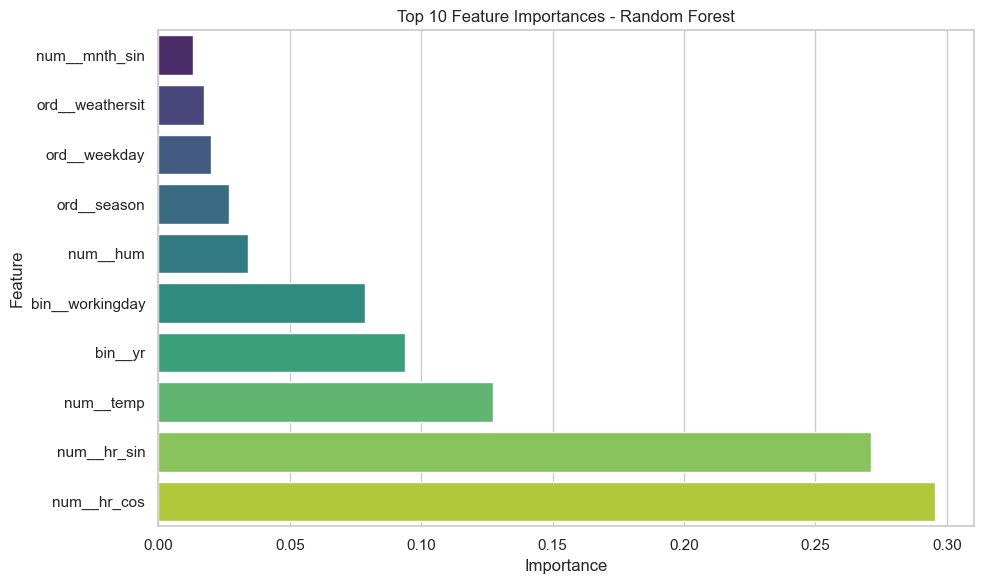

In [89]:
# Get feature names after preprocessing
feature_names = best_model.named_steps["preprocessor"].get_feature_names_out()

# Get importance values from the regressor
importances = best_model.named_steps["regressor"].feature_importances_

# Build importance table
fi_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

top10 = fi_df.head(10).sort_values("importance", ascending=True)

plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=top10,
    x="importance",
    y="feature",
    hue="feature",
    palette="viridis",
    legend=False
)
ax.set_title("Top 10 Feature Importances - Random Forest")
ax.set_xlabel("Importance")
ax.set_ylabel("Feature")
plt.tight_layout()
plt.show()

Feature importance from the tuned Random Forest shows that the most influential predictors of bike demand are the hour-based cyclical features, especially `num__hr_cos` and `num__hr_sin`, followed by temperature. This indicates that demand is primarily shaped by time-of-day patterns and weather conditions, while year and working-day indicators provide secondary explanatory power.

In [101]:
import numpy as np
from sklearn.metrics import mean_absolute_percentage_error, r2_score, mean_absolute_error, root_mean_squared_error
from sklearn.model_selection import cross_val_score
from scipy import stats

def comprehensive_evaluation(model, X_train, X_test, y_train, y_test, cv=5):
    model.fit(X_train, y_train)
    y_pred_test = model.predict(X_test)

    y_test = np.array(y_test).flatten()
    residuals = y_test - y_pred_test

    metrics = {
        'R²': r2_score(y_test, y_pred_test),
        'RMSE': root_mean_squared_error(y_test, y_pred_test),
        'MAE': mean_absolute_error(y_test, y_pred_test),
        'MAPE': mean_absolute_percentage_error(y_test, y_pred_test) * 100
    }

    cv_scores = cross_val_score(model, X_train, y_train, cv=cv, scoring="r2")

    print("=== MODEL EVALUATION REPORT ===")
    print(f"Model Type: {type(model).__name__}")
    print(f"Training Samples: {len(X_train)}")
    print(f"Test Samples: {len(X_test)}")
    print()

    print("Performance Metrics:")
    for k, v in metrics.items():
        print(f"  {k}: {v:.3f}")
    print(f"  CV R2: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")
    print()

    print("Model Diagnostics:")
    print(f"  Residual mean: {residuals.mean():.6f}")
    print(f"  Residual std: {residuals.std():.3f}")
    print(f"  Residual skew: {stats.skew(residuals):.3f}")
    print(f"  Residual kurtosis: {stats.kurtosis(residuals):.3f}")
    print()

    if metrics["R²"] >= 0.8:
        recommendation = "✅ Model looks strong and is likely deployment-ready."
    elif metrics["R²"] >= 0.6:
        recommendation = "⚠️ Model is usable but should be monitored and improved."
    else:
        recommendation = "❌ Model needs further improvement before deployment."

    print("Recommendation:")
    print(f"  {recommendation}")

    return {
        "metrics": metrics,
        "cv_scores": cv_scores,
        "residuals": residuals
    }
    
results = comprehensive_evaluation(model, X_train, X_test, y_train, y_test)
print(results)

=== MODEL EVALUATION REPORT ===
Model Type: RandomForestRegressor
Training Samples: 16635
Test Samples: 742

Performance Metrics:
  R²: 0.815
  RMSE: 70.805
  MAE: 43.105
  MAPE: 65.748
  CV R2: 0.815 ± 0.070

Model Diagnostics:
  Residual mean: -5.315328
  Residual std: 70.605
  Residual skew: 0.593
  Residual kurtosis: 7.116

Recommendation:
  ✅ Model looks strong and is likely deployment-ready.
{'metrics': {'R²': 0.815373562717596, 'RMSE': 70.80470046684215, 'MAE': 43.105005840071875, 'MAPE': 65.74801738181493}, 'cv_scores': array([0.69208952, 0.88944035, 0.79687252, 0.82709334, 0.87042764]), 'residuals': array([ 2.54200000e+01,  5.86600000e+01,  9.93700000e+01,  1.42300000e+02,
        7.94500000e+01,  4.23500000e+01,  7.92300000e+01,  7.45400000e+01,
        8.90800000e+01,  2.12570000e+02,  2.35640000e+02,  1.46000000e+01,
        9.68900000e+01, -1.33700000e+01, -5.48100000e+01, -4.05000000e+00,
       -4.65000000e+00, -3.24000000e+00,  1.86830000e+02,  1.15000000e+01,
        2

### 📝 Result

The tuned Random Forest achieved strong generalization performance, with a test `R2` of `0.815` and cross-validation `R2 0.815 +- 0.070`. `RMSE` was `70.805` and `MAE` was `43.105`, indicating solid predictive accuracy with some larger outlier errors. Residuals were centered close to zero but showed mild positive skew and heavy tails, suggesting occasional large misses. Feature importance analysis showed that hour-based cyclical features and temperature were the most influential predictors, confirming that bike demand is driven mainly by time-of-day and weather conditions.

### V.I. Bias, Fairness, and Explainability

We need to compare error metrics across groups such as:

* `workingday` vs non-working day.

* `season`.

* `weathersit`.

* `weekday` or time-of-day buckets.

A model is potentially biased if one group consistently has much higher error than another group, even when overall performance looks good. This is especially important because aggregate metrics can hide subgroup underperformance.

In [106]:
def check_group_bias(y_true, y_pred, groups):
    y_true_arr = np.ravel(y_true)
    y_pred_arr = np.ravel(y_pred)

    results = []
    for group in np.unique(groups):
        mask = groups == group
        results.append({
            "group": group,
            "count": mask.sum(),
            "RMSE": root_mean_squared_error(y_true_arr[mask], y_pred_arr[mask]),
            "MAE": mean_absolute_error(y_true_arr[mask], y_pred_arr[mask]),
            "bias_mean_error": np.mean(y_true_arr[mask] - y_pred_arr[mask])
        })

    return pd.DataFrame(results).sort_values("RMSE", ascending=False)

In [123]:
y_pred = model.predict(X_test)

column_name = "workingday"
print(f"--- Bias Report for: {column_name} ---")
group_bias = check_group_bias(y_test, y_pred, X_test[column_name].values)
display(group_bias)

--- Bias Report for: workingday ---


,group,count,RMSE,MAE,bias_mean_error
1,1,479,73.720852,42.356523,-3.982158
0,0,263,65.159086,44.468213,-7.743422


In [124]:
column_name = "season"
print(f"--- Bias Report for: {column_name} ---")
group_bias = check_group_bias(y_test, y_pred, X_test[column_name].values)
display(group_bias)

--- Bias Report for: season ---


,group,count,RMSE,MAE,bias_mean_error
0,1,262,79.066952,54.582211,-43.037885
1,4,480,65.859036,36.840365,15.274900


In [125]:
column_name = "weathersit"
print(f"--- Bias Report for: {column_name} ---")
group_bias = check_group_bias(y_test, y_pred, X_test[column_name].values)
display(group_bias)

--- Bias Report for: weathersit ---


,group,count,RMSE,MAE,bias_mean_error
2,3,70,81.569946,59.756929,-33.042357
1,2,337,70.246145,42.916778,2.939271
0,1,335,68.918800,39.814851,-7.825501


In [126]:
column_name = "weekday"
print(f"--- Bias Report for: {column_name} ---")
group_bias = check_group_bias(y_test, y_pred, X_test[column_name].values)
display(group_bias)

--- Bias Report for: weekday ---


,group,count,RMSE,MAE,bias_mean_error
1,1,119,102.457578,60.241387,-0.274244
2,2,95,72.745616,42.954221,-3.951674
3,3,96,67.578234,39.104028,-12.839601
6,6,120,63.889339,43.458250,8.916417
4,4,96,63.495202,37.492613,-18.222505
0,0,120,55.874674,38.348750,-10.234917
5,5,96,53.814848,37.129384,-4.122370


### 📃 Interpretation
Bias analysis was performed by comparing prediction error across weekday, weather, season, and working-day groups. The model showed uneven performance across subgroups, with some conditions producing noticeably higher RMSE and stronger over- or under-prediction. This indicates **conditional bias**, meaning the model is more reliable for certain operating contexts than others.

In [132]:
from pathlib import Path

# Model Documentation Card
def generate_model_card(model, X_test, y_test, groups, report_path="../outputs/reports/model_card.txt"):
    predictions = model.predict(X_test)

    card = {
        "model_type": type(model).__name__,
        "training_date": "2026-04-22",
        "features": list(X_test.columns),
        "performance": {
            "overall_r2": r2_score(y_test, predictions),
            "rmse": np.sqrt(mean_squared_error(y_test, predictions)),
            "mae": mean_absolute_error(y_test, predictions)
        },
        "fairness_analysis": {},
        "limitations": [
            "Performance may vary across subgroups.",
            "The model may still produce larger errors for rare conditions.",
            "This model should be monitored after deployment for drift and subgroup performance."
        ],
        "intended_use": "Regression prediction for bike demand forecasting and operational planning."
    }

    for group in np.unique(groups):
        mask = groups == group
        group_r2 = r2_score(y_test[mask], predictions[mask])
        group_rmse = np.sqrt(mean_squared_error(y_test[mask], predictions[mask]))
        group_mae = mean_absolute_error(y_test[mask], predictions[mask])

        card["fairness_analysis"][f"group_{group}"] = {
            "count": int(mask.sum()),
            "r2": group_r2,
            "rmse": group_rmse,
            "mae": group_mae
        }


    lines = []
    lines.append("MODEL DOCUMENTATION CARD")
    lines.append("=" * 40)
    lines.append(f"Model type: {card['model_type']}")
    lines.append(f"Training date: {card['training_date']}")
    lines.append("")
    lines.append("INTENDED USE")
    lines.append(card["intended_use"])
    lines.append("")
    lines.append("FEATURES")
    lines.append(", ".join(card["features"]))
    lines.append("")
    lines.append("OVERALL PERFORMANCE")
    lines.append(f"R²: {card['performance']['overall_r2']:.3f}")
    lines.append(f"RMSE: {card['performance']['rmse']:.3f}")
    lines.append(f"MAE: {card['performance']['mae']:.3f}")
    lines.append("")
    lines.append("FAIRNESS / GROUP ANALYSIS")

    for group, vals in card["fairness_analysis"].items():
        lines.append(f"- {group}")
        lines.append(f"  Count: {vals['count']}")
        lines.append(f"  R²: {vals['r2']:.3f}")
        lines.append(f"  RMSE: {vals['rmse']:.3f}")
        lines.append(f"  MAE: {vals['mae']:.3f}")

    lines.append("")
    lines.append("LIMITATIONS")
    for item in card["limitations"]:
        lines.append(f"- {item}")

    report_text = "\n".join(lines)

    path = Path(report_path)
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text(report_text, encoding="utf-8")

    return card, report_text

In [138]:
card, text = generate_model_card(
    model,
    X_test,
    y_test,
    X_test["weekday"],
    report_path="../outputs/reports/model_card_weekday.txt"
)

card, text = generate_model_card(
    model,
    X_test,
    y_test,
    X_test["season"],
    report_path="../outputs/reports/model_card_season.txt"
)

card, text = generate_model_card(
    model,
    X_test,
    y_test,
    X_test["weathersit"],
    report_path="../outputs/reports/model_card_weathersit.txt"
)

card, text = generate_model_card(
    model,
    X_test,
    y_test,
    X_test["workingday"],
    report_path="../outputs/reports/model_card_workingday.txt"
)

To **see** the documentation, please head to the directory `outputs/reports/`

### Bias Report Justification

To assess whether the model performs consistently across important operating conditions, I evaluated subgroup error on four key variables: `weekday`, `workingday`, `season`, and `weathersit`. These groups were chosen because they capture the main temporal and weather-related contexts that influence bike demand and are the most relevant slices for operational fairness in this project. I did not run separate bias checks on every feature, because many variables are numeric predictors rather than meaningful subgroup identifiers, and duplicating the same analysis across all columns wouldn't add any value. Instead, I focused on the features most likely to reveal meaningful performance differences across real-world usage conditions.

Please refer to the `data_dictionary.md` file to aid you in interpreting what each number corresponds to.

In [141]:
def create_bias_report(predictions, actuals, groups, group_names=None):
    """Create stakeholder-friendly bias report"""

    predictions = np.ravel(predictions)
    actuals = np.ravel(actuals)
    groups = np.ravel(groups)

    report = {
        "executive_summary": {},
        "technical_details": {},
        "recommendations": []
    }

    overall_accuracy = 1 - mean_squared_error(actuals, predictions) / np.var(actuals)
    report["executive_summary"]["overall_performance"] = f"{overall_accuracy:.1%}"

    group_performance = {}
    group_details = {}

    unique_groups = np.unique(groups)

    for i, group in enumerate(unique_groups):
        mask = groups == group

        if mask.sum() > 1 and np.var(actuals[mask]) != 0:
            group_acc = 1 - mean_squared_error(actuals[mask], predictions[mask]) / np.var(actuals[mask])
        else:
            group_acc = np.nan

        group_name = group_names[i] if group_names and i < len(group_names) else f"Group {group}"

        group_performance[group_name] = round(group_acc * 100, 1) if not np.isnan(group_acc) else None
        group_details[group_name] = {
            "count": int(mask.sum()),
            "r2_like_score": round(float(group_acc), 4) if not np.isnan(group_acc) else None,
            "rmse": round(float(np.sqrt(mean_squared_error(actuals[mask], predictions[mask]))), 3) if mask.sum() > 1 else None,
            "mae": round(float(mean_absolute_error(actuals[mask], predictions[mask])), 3) if mask.sum() > 1 else None,
            "bias_mean_error": round(float(np.mean(actuals[mask] - predictions[mask])), 3) if mask.sum() > 1 else None
        }

    report["executive_summary"]["group_performance"] = {
        k: (f"{v:.1f}%" if v is not None else "N/A")
        for k, v in group_performance.items()
    }
    report["technical_details"]["group_metrics"] = group_details

    valid_scores = [v for v in group_performance.values() if v is not None]
    if len(valid_scores) > 1:
        max_diff = (max(valid_scores) - min(valid_scores)) / 100
        report["technical_details"]["max_performance_gap"] = f"{max_diff:.1%}"

        if max_diff > 0.10:
            report["recommendations"].append("Consider bias mitigation or subgroup-specific monitoring.")
        else:
            report["recommendations"].append("Bias gaps are moderate; continue monitoring subgroup performance.")

    return report


def save_bias_report(report, title, report_path):
    """Save a readable bias report to a text file"""

    path = Path(report_path)
    path.parent.mkdir(parents=True, exist_ok=True)

    lines = []
    lines.append(f"--- Bias Report for: {title} ---")
    lines.append("")
    lines.append("Executive Summary")
    lines.append(f"Overall performance: {report['executive_summary']['overall_performance']}")
    lines.append("Group performance:")

    for group_name, perf in report["executive_summary"]["group_performance"].items():
        lines.append(f"- {group_name}: {perf}")

    lines.append("")
    lines.append("Technical Details")
    for group_name, vals in report["technical_details"]["group_metrics"].items():
        lines.append(f"- {group_name}")
        lines.append(f"  Count: {vals['count']}")
        lines.append(f"  R2-like score: {vals['r2_like_score']}")
        lines.append(f"  RMSE: {vals['rmse']}")
        lines.append(f"  MAE: {vals['mae']}")
        lines.append(f"  Bias mean error: {vals['bias_mean_error']}")

    if "max_performance_gap" in report["technical_details"]:
        lines.append(f"Max performance gap: {report['technical_details']['max_performance_gap']}")

    lines.append("")
    lines.append("Recommendations")
    for rec in report["recommendations"]:
        lines.append(f"- {rec}")

    report_text = "\n".join(lines)
    path.write_text(report_text, encoding="utf-8")
    return report_text


# Predictions
predictions = model.predict(X_test)

# Weekday report
weekday_names = [f"Day {g}" for g in np.unique(X_test["weekday"])]
weekday_report = create_bias_report(predictions, y_test, X_test["weekday"], weekday_names)
weekday_text = save_bias_report(weekday_report, "weekday", "../outputs/reports/bias_report_weekday.txt")

# Season report
season_names = [f"Season {g}" for g in np.unique(X_test["season"])]
season_report = create_bias_report(predictions, y_test, X_test["season"], season_names)
season_text = save_bias_report(season_report, "season", "../outputs/reports/bias_report_season.txt")

# Weathersit report
weather_names = [f"Weather {g}" for g in np.unique(X_test["weathersit"])]
weather_report = create_bias_report(predictions, y_test, X_test["weathersit"], weather_names)
weather_text = save_bias_report(weather_report, "weathersit", "../outputs/reports/bias_report_weathersit.txt")

# Working day report
workingday_names = [f"Working day {g}" for g in np.unique(X_test["workingday"])]
workingday_report = create_bias_report(predictions, y_test, X_test["workingday"], workingday_names)
workingday_text = save_bias_report(workingday_report, "workingday", "../outputs/reports/bias_report_workingday.txt")

### ⚖️ Legal and Ethical Considerations

In [144]:
def compliance_checklist(model_info, report_path="../outputs/reports/compliance_report.txt"):
    """Simple compliance checklist for model deployment and save it to a file"""

    checklist = {
        "data_consent": False,
        "bias_testing": False,
        "documentation": False,
        "explainability": False,
        "monitoring_plan": False
    }

    required_docs = [
        "data_source",
        "training_process",
        "bias_analysis",
        "intended_use",
        "limitations"
    ]

    if all(doc in model_info for doc in required_docs):
        checklist["documentation"] = True

    if "bias_testing_results" in model_info:
        checklist["bias_testing"] = True

    if "feature_importance" in model_info or "model_card" in model_info:
        checklist["explainability"] = True

    if "monitoring_plan" in model_info:
        checklist["monitoring_plan"] = True

    if "data_source" in model_info and model_info["data_source"]:
        checklist["data_consent"] = True

    compliance_score = sum(checklist.values()) / len(checklist)

    lines = []
    lines.append("LEGAL AND ETHICAL COMPLIANCE CHECKLIST")
    lines.append("=" * 45)
    lines.append(f"Compliance score: {compliance_score:.1%}")
    lines.append("")
    lines.append("Checklist results:")
    for k, v in checklist.items():
        lines.append(f"- {k}: {v}")
    lines.append("")
    lines.append("Missing requirements:")
    missing = [k for k, v in checklist.items() if not v]
    lines.append(", ".join(missing) if missing else "None")

    report_text = "\n".join(lines)

    path = Path(report_path)
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text(report_text, encoding="utf-8")

    return checklist, compliance_score, report_text


# Example compliance check
model_info = {
    "data_source": "UCI Bike Sharing Dataset",
    "training_process": "Random Forest with cross-validation and hyperparameter tuning",
    "bias_analysis": "Completed across weekday, season, weathersit, and workingday",
    "bias_testing_results": {"weekday": 0.82, "season": 0.79},
    "feature_importance": "Completed",
    "intended_use": "Bike demand forecasting and operational planning",
    "limitations": [
        "Performance varies across subgroups.",
        "The model may underperform on rare conditions."
    ],
    "monitoring_plan": "Monitor subgroup performance and retrain if drift is detected."
}

compliance, score, report_text = compliance_checklist(
    model_info,
    report_path="../outputs/reports/compliance_report.txt"
)

print("Head over to /reports to see the result")

Head over to /reports to see the result


### 🧮 Permutation Importance

Permutation Importance - Top 10 Features
   feature  importance_mean  importance_std
    hr_cos         0.888457        0.066690
    hr_sin         0.382574        0.023753
workingday         0.302708        0.033068
      temp         0.126593        0.011932
    season         0.107399        0.013838
weathersit         0.028081        0.005065
       hum         0.021371        0.015880
   weekday         0.010977        0.003002
 windspeed         0.007105        0.001812
   holiday         0.001139        0.000520


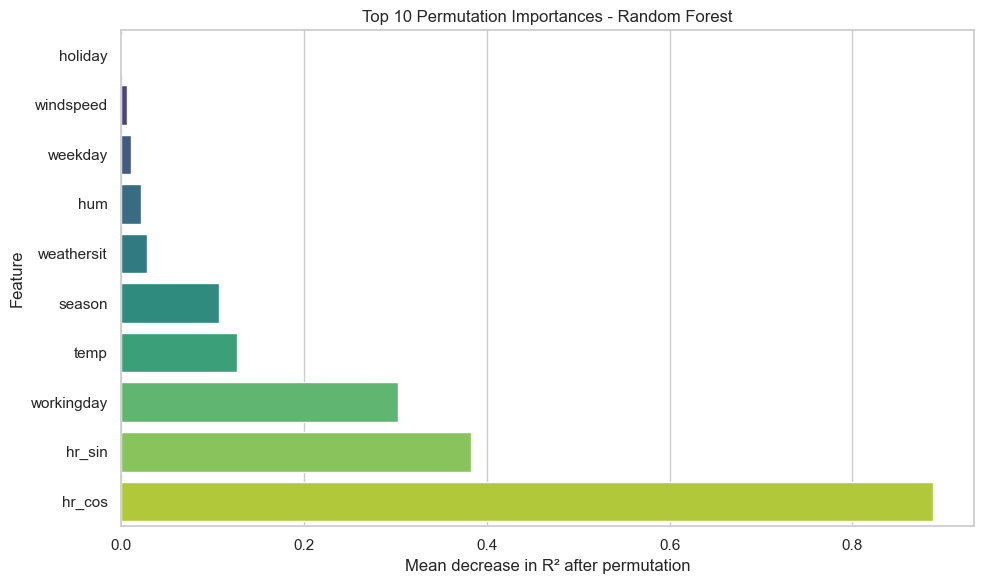

In [145]:
from sklearn.inspection import permutation_importance

def calculate_permutation_importance(model, X_test, y_test, n_repeats=10, scoring="r2"):
    """Calculate permutation importance for a fitted model"""

    result = permutation_importance(
        model,
        X_test,
        y_test,
        n_repeats=n_repeats,
        random_state=42,
        scoring=scoring
    )

    importance_df = pd.DataFrame({
        "feature": X_test.columns,
        "importance_mean": result.importances_mean,
        "importance_std": result.importances_std
    }).sort_values("importance_mean", ascending=False)

    return importance_df


# Calculate permutation importance
perm_importance_df = calculate_permutation_importance(model, X_test, y_test, n_repeats=10, scoring="r2")

# Print top 10
print("Permutation Importance - Top 10 Features")
print(perm_importance_df.head(10).to_string(index=False))

# Define paths
report_dir = Path("../outputs/reports")
figures_dir = Path("../outputs/figures")

report_dir.mkdir(parents=True, exist_ok=True)

perm_importance_df.to_csv(report_dir / "permutation_importance.csv", index=False)

# Plot top 10
top10 = perm_importance_df.head(10).sort_values("importance_mean", ascending=True)

plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=top10,
    x="importance_mean",
    y="feature",
    hue="feature",
    palette="viridis",
    legend=False
)
ax.set_title("Top 10 Permutation Importances - Random Forest")
ax.set_xlabel("Mean decrease in R² after permutation")
ax.set_ylabel("Feature")
plt.tight_layout()

plt.savefig(figures_dir / "permutation_importance.png", dpi=300, bbox_inches="tight")
plt.show()

### 👩🏻‍🔬 Interpretation

Permutation importance shows that **the model depends most strongly on hour-based cyclical features**, especially `hr_cos` and `hr_sin`, followed by `workingday`, `temp`, and `season`. This suggests that **bike demand is primarily driven by time-of-day patterns, working-day context, and weather-related conditions.** Several calendar features, including `yr`, `mnth_sin`, and `mnth_cos`, have negligible effect on the fitted model’s predictions.

# VI. Limitations, Ethics & Impact